# Spotify Analytics 

## Read in the DataFrame

In [7]:
import pandas as pd

df = pd.read_csv('./spotify.csv')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Central Tendency

In [5]:
mean = df['in_spotify_playlists'].mean()
median = df['in_spotify_playlists'].median()

# we can use the stats class from the scipy package
from scipy import stats
mode = stats.mode(df['in_spotify_playlists'])

print(f"Mean:   {mean}")
print(f"Median: {median}")
print(f"Mode:   {mode[0]}")

Mean:   5202.56512605042
Median: 2216.5
Mode:   86


## Boxplot Analysis

In order to do plotting, we need to import the `pyplot` class from the `matplotlib` module.

In [2]:
import matplotlib.pyplot as plt

plt.boxplot(df['bpm'], vert=False)
plt.show()

NameError: name 'df' is not defined

# Five Number Summary (FNS)

I want the FNS of the `bpm` column.

- Min
- Lower quartile / Q1 (25%)
- Median / Q2 (50%)
- Upper quartile / Q3 (75%)
- Max

We can use the `numpy` package to calculate these values.

In [4]:
import numpy as np

min = np.min(df.bpm) # df.bpm is the same as df['bpm']
q1 = np.percentile(df.bpm, 25)
med = np.median(df.bpm)
q3 = np.percentile(df.bpm, 75)
max = np.max(df.bpm)

# we could do this on one line (see below)
# five_num_summary = np.percentile(df.bpm, [0, 25, 50, 75, 100])

print('------------ FNS -------------')
print(f"Min: {min}")
print(f"Q1: {q1}")
print(f"Median: {med}")
print(f"Q3: {q3}")
print(f"Max: {max}")



------------ FNS -------------
Min: 65
Q1: 99.75
Median: 121.0
Q3: 140.25
Max: 206


## FNS as a Function

In [5]:
def fns(column):
    min = np.min(df[column]) 
    q1 = np.percentile(df[column], 25)
    med = np.median(df[column])
    q3 = np.percentile(df[column], 75)
    max = np.max(df[column])

    print(f'------------ FNS for {column.capitalize()} -------------')
    print(f"Min: {min}")
    print(f"Q1: {q1}")
    print(f"Median: {med}")
    print(f"Q3: {q3}")
    print(f"Max: {max}")

fns('bpm')
fns('streams')
fns('released_year')

------------ FNS for Bpm -------------
Min: 65
Q1: 99.75
Median: 121.0
Q3: 140.25
Max: 206
------------ FNS for Streams -------------
Min: 2762
Q1: 141636175.0
Median: 290530915.0
Q3: 673869022.0
Max: 3703895074
------------ FNS for Released_year -------------
Min: 1930
Q1: 2020.0
Median: 2022.0
Q3: 2022.0
Max: 2023


## IQR, Outliers, Standard Deviation, and Variance

In [6]:
iqr = q3 - q1 # Interquartile range for bpm column
upper_limit = (1.5 * iqr) + q3
lower_limit = q1 - (1.5 * iqr)

print(f"Interquartile Range: {iqr}")
print(f"Upper Limit:         {upper_limit}")
print(f"Lower Limit:         {lower_limit}")

standard_dev = df['bpm'].std()
print()
print(f"Standard Deviation:  {standard_dev:.2f}")

variance = standard_dev ** 2 # x ** y is the same as 'x to the power of y'
print(f"Variance:            {variance:.2f}")

Interquartile Range: 40.5
Upper Limit:         201.0
Lower Limit:         39.0

Standard Deviation:  28.07
Variance:            787.90


## Histogram

I want a histogram for the `released_month` column.

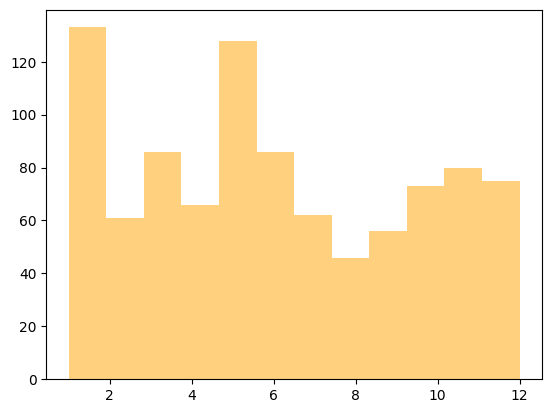

In [12]:
plt.hist(df['released_month'], bins=12, color='orange', alpha=0.5)
plt.show()

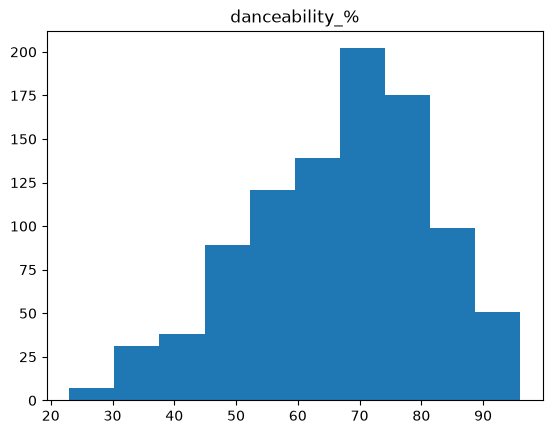

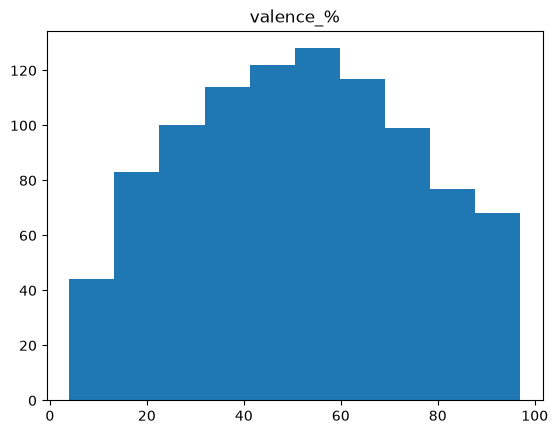

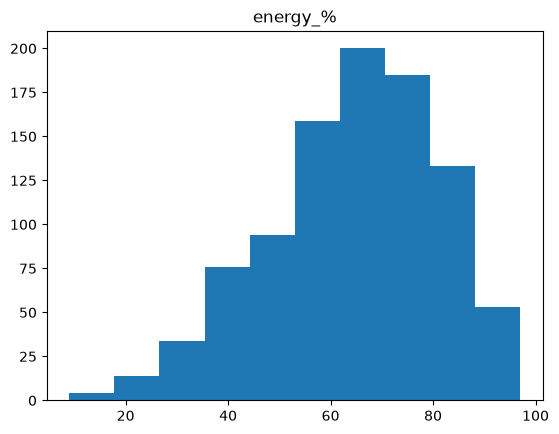

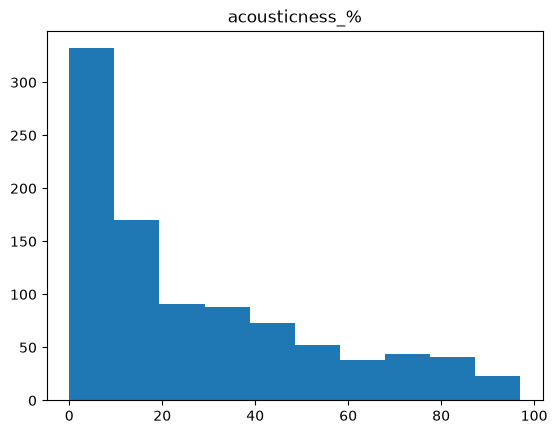

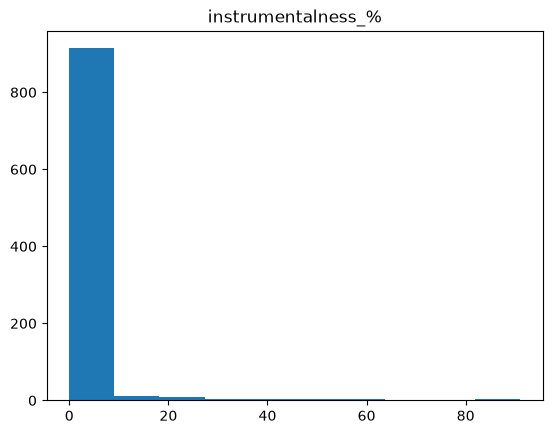

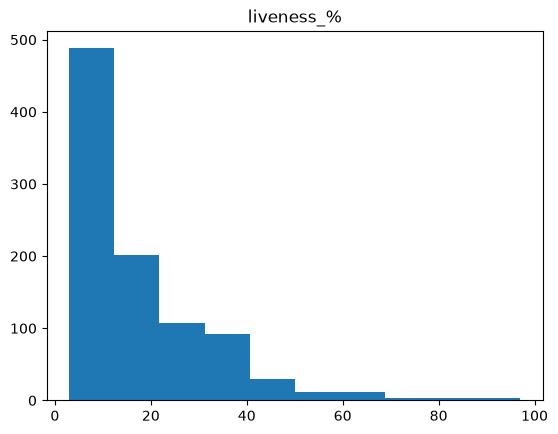

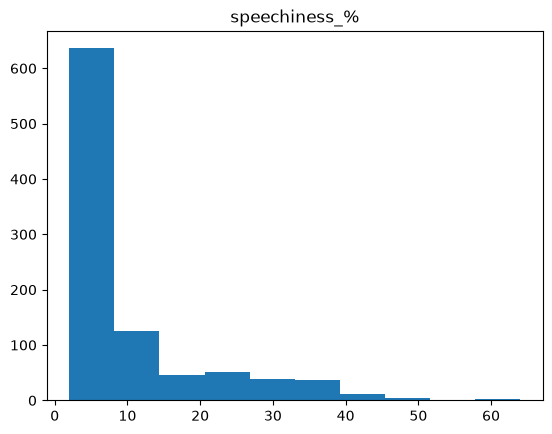

: 

In [ ]:
# Histogram for the Columns
import matplotlib.pyplot as plt
columns = [
    "danceability_%",
    "valence_%",
    "energy_%",
    "acousticness_%",
    "instrumentalness_%",
    "liveness_%",
    "speechiness_%"
]

for column in columns:
    plt.hist(df[column])
    plt.title(column)
    plt.show() #this separates the histograms


## Scatter Plot

I want a scatter plot to compare `streams` and `in_spotify_playlists`.

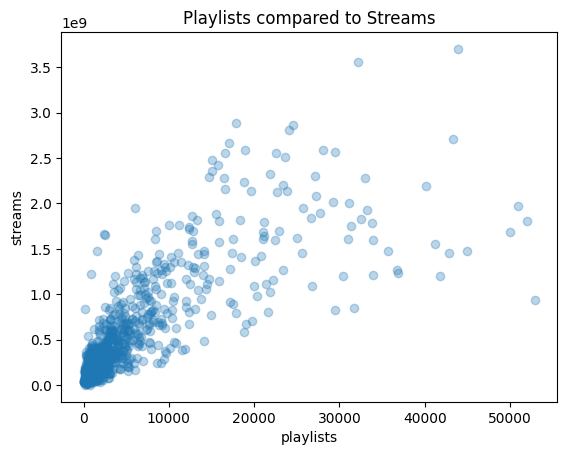

In [13]:
plt.scatter(x=df['in_spotify_playlists'], y = df['streams'], alpha=0.3)
plt.title("Playlists compared to Streams")
plt.xlabel('playlists')
plt.ylabel("streams")
plt.show()

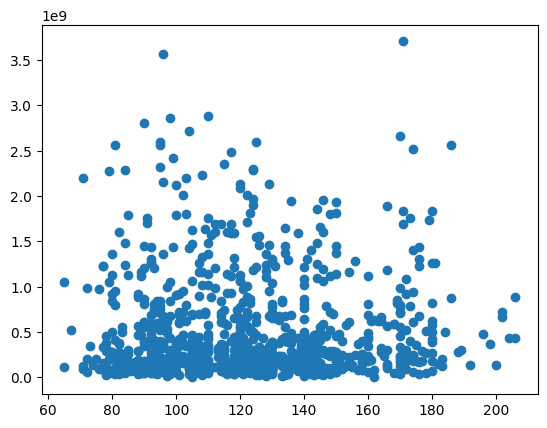

In [9]:
plt.scatter(x = df['bpm'], y = df['streams'])
plt.show()


C:\Users\aphil\AppData\Local\Temp\ipykernel_25052\56585882.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot([df[f] for f in features], vert = False, tick_labels= features)


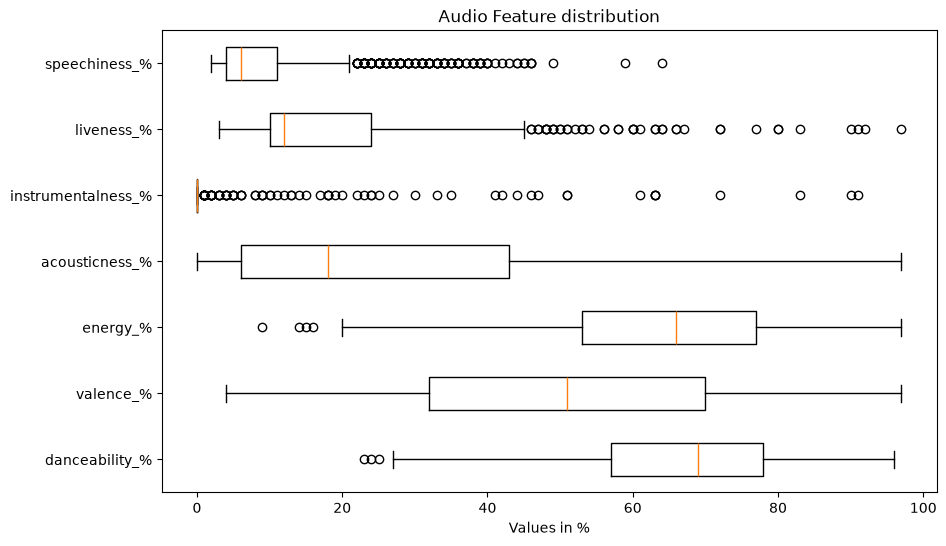

In [8]:
# Boxplot for audio features

features = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
plt.figure(figsize= (10,6))
plt.boxplot([df[f] for f in features], vert = False, tick_labels= features)
plt.title("Audio Feature distribution")
plt.xlabel("Values in %")
plt.show()

Interpret the result of the boxplot for the audio features

Across the seven audio features, danceability and energy exhibit the highest medians with the most compact, tightly agreed-upon spreads, indicating that most tracks in the dataset are consistently energetic and danceable; valence sits at a moderate median but with the widest spread, showing that songs vary broadly in emotional tone from sad to happy; while speechiness, liveness, acousticness, and instrumentalness all cluster near the low end of the scale with narrow interquartile ranges, confirming that the dataset is dominated by conventional, highly-produced, vocal-centered tracks rather than spoken-word, live, acoustic, or purely instrumental content.

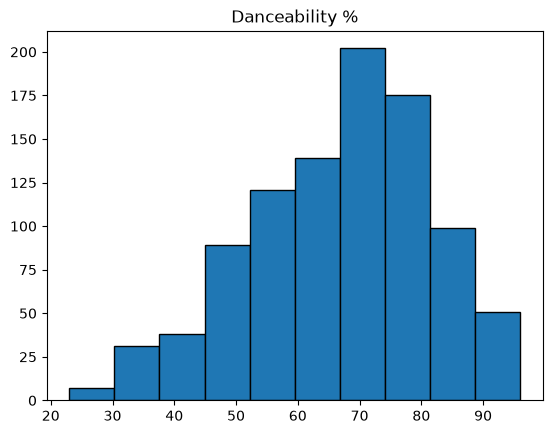

(array([  7.,  31.,  38.,  89., 121., 139., 202., 175.,  99.,  51.]), array([23. , 30.3, 37.6, 44.9, 52.2, 59.5, 66.8, 74.1, 81.4, 88.7, 96. ]), <BarContainer object of 10 artists>)


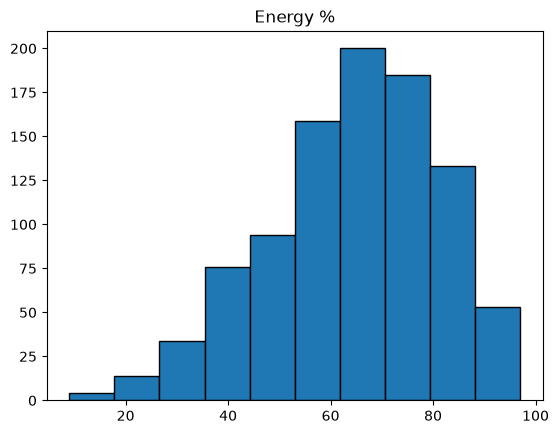

(array([  4.,  14.,  34.,  76.,  94., 159., 200., 185., 133.,  53.]), array([ 9. , 17.8, 26.6, 35.4, 44.2, 53. , 61.8, 70.6, 79.4, 88.2, 97. ]), <BarContainer object of 10 artists>)


,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,9.520000e+02,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000,952.000000
mean,1.556723,2018.288866,6.038866,13.944328,5202.565126,12.022059,5.141374e+08,67.866597,51.963235,2.669118,122.553571,66.984244,51.406513,64.274160,27.078782,1.582983,18.214286,10.138655
std,0.893331,11.011397,3.564571,9.197223,7901.400683,19.582405,5.668569e+08,86.470591,50.628850,6.038152,28.069601,14.631282,23.480526,16.558517,26.001599,8.414064,13.718374,9.915399
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,65.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,874.500000,0.000000,1.416362e+08,13.000000,7.000000,0.000000,99.750000,57.000000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2216.500000,3.000000,2.905309e+08,34.000000,38.500000,0.000000,121.000000,69.000000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5573.750000,16.000000,6.738690e+08,88.000000,87.000000,2.000000,140.250000,78.000000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,58.000000,206.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [19]:
# Display histogram for danceability and energy audio features

danceability = plt.hist(df["danceability_%"], edgecolor ='black')
plt.title("Danceability %")
plt.show()
print(danceability)


energy = plt.hist(df["energy_%"], edgecolor = 'black')
plt.title("Energy %")
plt.show()
print(energy)


df.describe()

released_year
1930      1
1942      1
1946      1
1950      1
1952      1
1957      2
1958      3
1959      2
1963      3
1968      1
1970      1
1971      1
1973      1
1975      2
1979      1
1982      2
1983      1
1984      4
1985      2
1986      2
1987      1
1991      2
1992      1
1994      1
1995      2
1996      1
1997      1
1998      1
1999      5
2000      4
2002      6
2003      2
2004      4
2005      1
2007      1
2008      2
2010      7
2011     10
2012     10
2013     13
2014     13
2015     11
2016     18
2017     23
2018     10
2019     36
2020     37
2021    119
2022    402
2023    175
Name: count, dtype: int64


(array([47.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([  1. ,  41.1,  81.2, 121.3, 161.4, 201.5, 241.6, 281.7, 321.8,
        361.9, 402. ]),
 <BarContainer object of 10 artists>)

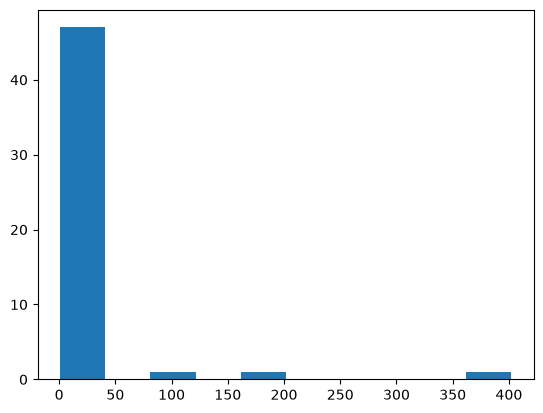

In [25]:
# Show how many songs were released each year based on the released_year feature
print(df["released_year"].value_counts().sort_index())

plt.hist(df["released_year"].value_counts().sort_index())